In [60]:
import os

from pathlib import Path
from typing import TypedDict, List, Annotated, Literal, Optional, Dict
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END

from langchain_openrouter import ChatOpenRouter
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_community.vectorstores import InMemoryVectorStore

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters  import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

from langchain_core.prompts import ChatPromptTemplate
import operator
from langchain_core.tools import tool
from dotenv import load_dotenv

In [61]:
# states
class PaperSummary(BaseModel):
    title: str = Field(...,description="The official title of the paper")
    problem_domain: str = Field(..., description="The specific problem being solved (e.g., Tabular Data Classification, Time Series Forecasting).")
    authors: List[str] = Field(..., description="List of the paper's authors.")
    publication_year: Optional[int] = Field(default=None, description="The year the paper was published.")
    code_repository_url: Optional[str] = Field(
        default=None, 
        description="URL to the GitHub or code repository if provided in the text."
    )
    
    novel_architecture_proposed: Optional[str] = Field(
        default=None,
        description="Name of the new model proposed (e.g., FT-Transformer) i.e the originality of this paper. Return null if it's a survey or comparative study."
    )
    models_evaluated: List[str] = Field(..., description="List of all models tested or compared (e.g., XGBoost, ResNet, TabNet). DO NOT include optimizers (e.g., Adam), regularization techniques (e.g., Dropout), or datasets.")
    datasets_used: List[str] = Field(..., description="List of specific datasets used for benchmarking (e.g., Adult, Higgs, California Housing).")
    
    evaluation_metrics: List[str] = Field(..., description="Metrics used to measure performance (e.g., RMSE, Accuracy, F1-score).")
    
    main_conclusion: str = Field(..., description="The primary finding or takeaway of the research.")
    key_limitations: Optional[str] = Field(
        default=None, 
        description="Any stated limitations, failures, or disadvantages mentioned by the authors."
    )
    research_gap_addressed: Optional[str] = Field(
        default=None, 
        description="The specific flaw or missing piece in existing literature this paper attempts to solve (e.g., 'Previous time-series forecasting models fail to capture long-term dependencies.')."
    )
    future_research_gaps: Optional[str] = Field(
        default=None, 
        description="Unsolved problems, open questions, or future work explicitly mentioned by the authors at the end of the paper."
    )

class ResearchGraphState(TypedDict):
    pdf_paths: List[str]
    user_query: str

    research_plan: List[str]
    current_step: str
    search_queries: List[str]

    extracted_summaries: List[PaperSummary]
    errors: List[str]
    retry_count: int

    final_comparison: Optional[str]


In [62]:
llm = ChatOpenRouter(
    model="cohere/north-mini-code:free",
    temperature=0
)

In [63]:
from langchain_openai import OpenAIEmbeddings
import os
load_dotenv()

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=os.getenv("OPENROUTER_API_KEY"), # type: ignore
    base_url="https://openrouter.ai/api/v1",
)

In [64]:
class Plan(BaseModel):
    steps: List[str] = Field( ..., description="A list of step-by-step subtasks required to resolve the user query."
    )

In [65]:
# This node generates plan from the user query

# def planner(state: ResearchGraphState) -> dict:
#     structured_llm=llm.with_structured_output(Plan)
#     plan=structured_llm.invoke([
#         SystemMessage(content=(
#     "You are an expert research planner. Breakdown the user query into smaller "
#     "subtasks which to be performed in a step-by-step fashion.\n\n"
#     "CRITICAL INSTRUCTION: You must respond ONLY with valid JSON matching the exact schema requested. "
#     "Do NOT wrap the JSON in markdown code blocks (e.g., ```json). "
#     "Do NOT include any conversational text, greetings, or explanations before or after the JSON. "
#     "Your entire response must start with { and end with }.\n\n"
#     "Example Query: 'Compare how these papers handle missing data.'\n"
#     "Example Output:\n"
#     "{\n"
#     "  \"steps\": [\n"
#     "    \"1. Extract datasets and models from all papers.\",\n"
#     "    \"2. Search specifically for methodology chunks mentioning 'missing data' or 'imputation'.\",\n"
#     "    \"3. Compare the imputation strategies.\"\n"
#     "  ]\n"
#     "}"
# )),
#         HumanMessage(content=f"Query: {state['user_query']}")
#     ])
#     if not plan:
#         print("Plan can't generated.")
#         return {'research_plan':""}
#     return {'research_plan':plan.steps}


from langchain_core.output_parsers import JsonOutputParser

def planner(state: ResearchGraphState) -> dict:
    parser = JsonOutputParser(pydantic_object=Plan)
    
    # We append the formatting instructions directly to the system prompt
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are an expert research planner. Breakdown the query into step-by-step subtasks.\n{format_instructions}"),
        ("human", "Query: {user_query}")
    ])
    
    # Pipe it into the parser instead of using with_structured_output
    chain = prompt | llm | parser
    
    plan_dict = chain.invoke({
        "user_query": state['user_query'],
        "format_instructions": parser.get_format_instructions()
    })
    
    # The parser returns a dictionary, so we access the key directly
    return {'research_plan': plan_dict['steps']}

In [66]:
# This node searches for the missing fields and error and keep a track on the retry iteration

def critic(state: ResearchGraphState) -> dict:
    summaries=state.get("extracted_summaries",[])
    missing_fields={}
    errors=[]

    for summary in summaries:
        missing=[]
        if not summary.models_evaluated:
            missing.append("models_evaluated")
        if not summary.datasets_used:
            missing.append("datasets_used")
        if not summary.evaluation_metrics:
            missing.append("evaluation_metrics")
        if not summary.authors:
            missing.append("authors")

        invalid_strings = ["","n/a","not specified","none mentioned","none"]
        
        if not summary.title or summary.title.lower() in invalid_strings:
            missing.append("title")
        if not summary.main_conclusion or summary.main_conclusion.lower() in invalid_strings:
            missing.append("main_conclusion")
        if not summary.problem_domain or summary.problem_domain.lower() in invalid_strings:
            missing.append("problem_domain")

        if missing:
            paper_name=summary.title if summary.title else "Unknown Paper"
            missing_fields[paper_name] = missing
            errors.append(f"Missing {', '.join(missing)} in paper: {paper_name}")
    retries=state.get('retry_count',0)
    return {
        "errors":errors,
        "retry_count": retries
    }


In [67]:
class SearchQuery(BaseModel):
    queries: List[str] = Field(...,description="A list of 2 to 3 highly specific vector search queries to find the missing information.")

In [68]:
# This node rewrites query for missing informations

def rewrite_query(state: ResearchGraphState) -> dict:
    errors=state.get("errors",[])
    error_string="\n".join(errors)
    structured_llm=llm.with_structured_output(SearchQuery)
    result=structured_llm.invoke([
        SystemMessage(content=("You are an AI assistant helping to fix incomplete document extractions. "
            "The previous extraction missed critical fields in a research paper. "
            "Look at the errors provided and generate highly specific search queries to find the missing information. "
            "For example, if 'datasets_used' is missing, generate a query like: 'we evaluate our model on the following datasets benchmark'.")),
        HumanMessage(content=f"Here are the missing fields from the previous extraction:\n{error_string}\n\nGenerate the new search queries.")    ])
    retries=state.get('retry_count',0)
    print(f"--- REWRITING QUERIES (Attempt {retries + 1}) ---")
    print(f"New Queries: {result.queries}")
    
    return {
        "search_queries": result.queries,
        "retry_count": retries + 1
    }

In [69]:
# This node finds all the info regarding a research ppr

def extract_paper_rag(state: ResearchGraphState) -> dict: # type: ignore
    summaries = []
    
    for pdf_path in state["pdf_paths"]:
        loader = PyPDFLoader(pdf_path)
        docs = loader.load()
        splitter = RecursiveCharacterTextSplitter(chunk_size=1200, chunk_overlap=200)
        chunks = splitter.split_documents(docs)
        
        vector_store = InMemoryVectorStore.from_documents(chunks, embeddings)
        retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})

        queries_to_run = state.get('search_queries', [])
        if not queries_to_run:
            queries_to_run = [
                "title, authors, abstract, introduction, problem domain, research gap",
                "models evaluated, novel architecture proposed, methodology",
                "datasets used, evaluation metrics, main conclusions, limitations"
            ]

        retrieved_chunks=[]
        for q in queries_to_run:
            chunks=retriever.invoke(q)
            retrieved_chunks.extend(chunks)

        unique_chunks = {c.page_content for c in retrieved_chunks}
        context = "\n\n".join(unique_chunks)

        structured_llm=llm.with_structured_output(PaperSummary)

        prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an expert AI researcher analyzing scientific literature. 
Your task is to extract highly accurate, factual information from the provided research paper text into the required structured format.

STRICT RULES:
1. ONLY extract information explicitly stated in the provided text.
2. DO NOT hallucinate, infer, or guess fields (especially datasets, metrics, and models).
3. If a field (like a code repository or future gap) is not mentioned in the text, leave it null/empty.
4. Keep textual summaries concise, technical, and objective."""),
    ("human", "Here is the text from the research paper:\n\n{context}\n\nExtract the requested information.")
])
        chain = prompt|structured_llm
        summary = chain.invoke({'context': context})

        summaries.append(summary)
        
    return {"extracted_summaries": summaries}


In [70]:
def comparison(state: ResearchGraphState) -> dict:
    summaries = state['extracted_summaries']
    user_query = state['user_query']
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a senior researcher. Compare the following extracted paper summaries."),
        ("human", """Here are the summaries of {num_papers} papers:

{summaries_json}

Provide:
1. A Markdown comparison matrix table of Models, Datasets, and Metrics.
2. Key points of agreement/conflict in their conclusions.
3. Identified research gaps across all papers.

Note: Directly address the user query below in your analysis.
USER QUERY: {user_query}""")
    ])

    summaries_text = "\n\n".join([s.model_dump_json(indent=2) for s in summaries])
    
    chain = prompt | llm
    response = chain.invoke({
        "num_papers": len(summaries), 
        "summaries_json": summaries_text, 
        "user_query": user_query
    })
    
    return {"final_comparison": response.content}

In [71]:
# This is to decide which path to take after the critic node

def path_after_critic(state: ResearchGraphState):
    errors=state.get("errors",[])
    retries=state.get("retry_count",0)
    MAX_RETRIES=3

    if errors and retries<MAX_RETRIES:
        print(f"Critic found errors: {errors}. Routing to retry...")
        return "rewrite_query"
    
    if errors and retries>=MAX_RETRIES:
        print("Max retries reached. Proceeding to comparison with limited data.")
        return "compare"
    
    print("Critic approved the extraction. Proceeding to comparison.")
    return "compare"


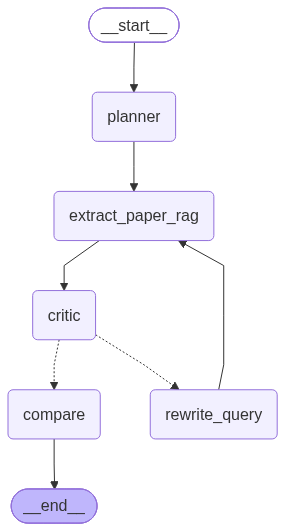

In [72]:
g=StateGraph(ResearchGraphState)

g.add_node("planner",planner)
g.add_node("extract_paper_rag",extract_paper_rag)
g.add_node("critic",critic)
g.add_node("rewrite_query",rewrite_query)
g.add_node("compare",comparison)

g.add_edge(START,"planner")
g.add_edge("planner","extract_paper_rag")
g.add_edge("extract_paper_rag","critic")
g.add_conditional_edges(
    "critic",
    path_after_critic,
    {
        "rewrite_query": "rewrite_query", # If function returns "rewrite_query", go to node "rewrite_query"
        "compare": "compare"              # If function returns "compare", go to node "compare"
    }
    )
g.add_edge("rewrite_query","extract_paper_rag")
g.add_edge("compare",END)

graph=g.compile()
graph


In [75]:
if __name__ == "__main__":
    initial_state = {
        "pdf_paths": ["pdf_1.pdf", "pdf_2.pdf"],
        "user_query": "Compare the performance benchmarks and identify the main conclusions regarding deep learning vs tree-based models.",
        "research_plan": [],
        "current_step": "",
        "search_queries": [],
        "extracted_summaries": [],
        "errors": [],
        "retry_count": 0,
        "final_comparison": None
    }

    # Execute the graph
    print("Starting Research Assistant Pipeline...")
    final_state = graph.invoke(initial_state)

    print("\n\n=== FINAL SYNTHESIS ===")
    print(final_state["final_comparison"])

Starting Research Assistant Pipeline...
Critic approved the extraction. Proceeding to comparison.


=== FINAL SYNTHESIS ===
## 1. Comparison Matrix (Models | Datasets | Metrics)

| Paper | Models Evaluated (excerpt) | Datasets Used | Evaluation Metrics |
|-------|----------------------------|---------------|--------------------|
| **Foundation Models for Tabular Classification** (Paper 1) | TabPFN, XTab, CARTE, TP‑BERTa, GBDT, AutoML, ICL, FT, FNN, Transformer, SAINT, MLP, ResNet, **FT‑Transformer**, TabNet, CatBoost, XGBoost, RealMLP | OpenMLCC18 (18 classification datasets) | ROC‑AUC |
| **Deep Learning Models for Tabular Data** (Paper 2) | ResNet, **FT‑Transformer**, MLP, GBDT | California Housing (regression), Adult, Helena, Jannis, Higgs, ALOI, Epsilon, Year, Covertype, Yahoo, Microsoft (mixed regression/classification) | RMSE (regression), Accuracy (classification) |

*Notes*  

- **FT‑Transformer** appears both as a model evaluated in Paper 1 and as the novel architecture introd